# HTDA-Mapper on plant descriptors (Poincaré-ball branch) — reproduction

**Paper:** Zdražil, Kong, Spíchal et al., *Hyperbolic topological data analysis Mapper reveals dynamic trait–environment patterns in plant phenomics*, Plant Phenomics 2026;8:100186 (doi:10.1016/j.plaphe.2026.100186).

**Scope of this notebook (partial demonstration):** reproduce the paper's descriptor-branch **HTDA-Mapper graph** (Fig. 5) by running the authors' pinned Poincaré-ball descriptor pipeline (the pipeline of `DesVisMain.py` + `configs/DesVisPBConfig.yaml`) on their embedded 27,761-plant × 7-descriptor table `datasets/DesVisPE.csv`, colouring nodes by `Growth_Condition_Binary`, with the published tuned hyperparameters (seed 9).

**Not included:** the raw-image branch (Figs. 4/6), contrastive SimCLR/BYOL training (no public checkpoints), the Euclidean pipelines, and hyperparameter re-optimisation.

> **AI-assisted adaptation notice (English):** The authors' hyperbolic components — `HyperbolicUMAP`, `GeomstatsKMeansCover`, `HyperbolicDBSCAN`, node statistics, colour mapping and the tuned YAML configuration — are used **unmodified** from commit `dac54cfff85e41f002e1fd6adade506129dd4112`. The generic Mapper *assembly and rendering glue* (giotto-tda's `make_mapper_pipeline` / `plot_static_mapper_graph`) was reimplemented in this notebook because giotto-tda has no wheels for Google Colab's current Python 3.13 (verified 2026-10-06) and building it from source is not viable there. The authors did not provide this Colab adaptation; the executed example was validated on a fresh CPU runtime, but untested behaviour is not guaranteed.
>
> **日本語（AI による翻訳・実装の注記）:** 著者の双曲幾何コンポーネント（HyperbolicUMAP / GeomstatsKMeansCover / HyperbolicDBSCAN、ノード統計、色マップ、チューニング済み YAML 設定）は pinned コミットから**改変せず**使用します。Colab の Python 3.13 に giotto-tda の wheel が存在しないため、Mapper の組立・描画の部分のみ本ノートブック内で再実装しました（著者提供の Colab 実装ではありません）。検証済みの実行例の外は動作保証されません。

- Paper: https://doi.org/10.1016/j.plaphe.2026.100186 (OA: https://pmc.ncbi.nlm.nih.gov/articles/PMC13316264/)
- Author code: https://github.com/JZdrazilX/MML @ `dac54cfff85e41f002e1fd6adade506129dd4112`


## 1. Runtime selection

**Select Runtime → Change runtime type → CPU (standard).** This pipeline contains no CUDA/GPU operations — the filter is UMAP with hyperboloid output metric (numba, CPU), the cover is Riemannian k-means (geomstats, CPU), clustering is DBSCAN per cover element, and rendering uses plotly+kaleido. A GPU would not speed up any faithful step.

**Run all** executes: dependency install → pinned code+data retrieval with hash verification → data preview → the authors' hyperbolic Mapper pipeline → displayed result graph.

Expected end-to-end time on a fresh standard CPU runtime: roughly 45–90 min (the Riemannian k-means cover over 27,761 points × 194 clusters dominates; measured sub-times are printed in the outputs). Downloads ≈ 60 MB of wheels + one 4.9 MB CSV.

**日本語:** ランタイムは「CPU（標準）」を選択してください。GPU を使う処理は含まれません。リマン幾何 k-means カバーが支配的で、すべて実行には約 45–90 分かかることがあります（実測値は各セルの出力に表示）。


## 2. Dependencies

**Purpose:** install the author pipeline's dependencies on this fresh runtime. `geomstats` 2.8.0 (Riemannian k-means and Poincaré-ball geometry), `umap-learn` (hyperboloid-output UMAP filter), `hdbscan` (imported by the authors' module), and `kaleido` 0.2.1 (self-contained PNG export backend for `plotly.write_image`). scikit-learn is left at the runtime's installed version. **Expected:** pip resolves cleanly and the version line prints.

**日本語:** 著者パイプラインの依存関係をインストールします。scikit-learn はランタイム既定の版を使います。


In [ ]:
%%time
!pip install -q --timeout 120 "geomstats==2.8.0" "umap-learn" "hdbscan" "kaleido==0.2.1" "pyyaml"
import geomstats, umap, hdbscan, sklearn, plotly, yaml
from importlib.metadata import version
print("geomstats", geomstats.__version__, "| umap-learn", umap.__version__,
      "| hdbscan", version("hdbscan"), "| sklearn", sklearn.__version__,
      "| plotly", plotly.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━ 6.5/10.5 MB 93.1 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/79.9 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━ 33.9/79.9 MB 149.4 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━ 69.1/79.9 MB 97.3 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 79.9/79.9 MB 178.4 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 79.9/79.9 MB 178.4 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 79.9/79.9 MB 178.4 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 11.7 MB/s eta 0:00:00


INFO:numexpr.utils:NumExpr defaulting to 2 threads.


geomstats 2.8.0 | umap-learn 0.5.12 | hdbscan 0.8.44 | sklearn 1.6.1 | plotly 5.24.1
CPU times: user 33.7 s, sys: 2.44 s, total: 36.1 s
Wall time: 49 s


## 3. Pinned author code and input data

**Purpose:** fetch the authors' repository at the exact verified commit `dac54cfff85e41f002e1fd6adade506129dd4112` as a *partial, blob-less clone with sparse checkout* (code + the single required CSV; no other datasets, no history), detached at that commit. **Expected:** checked-out HEAD equals the pinned SHA, and `datasets/DesVisPE.csv` (git blob `3b36e697496249573285e3394c55f0df65780a92`, 4,943,724 bytes) is present and hash-verified.

**日本語:** 著者リポジトリを検証済みコミットに部分クローンし、必要なコードと記述子 CSV のみ取得してハッシュ検証します。


In [ ]:
import subprocess, pathlib, hashlib

REPO = "https://github.com/JZdrazilX/MML"
PIN = "dac54cfff85e41f002e1fd6adade506129dd4112"
WS = pathlib.Path("/content/mml")

if not WS.exists():
    subprocess.run(["git", "clone", "--filter=blob:none", "--no-checkout",
                    "--sparse", REPO, str(WS)], check=True)
def git(*a): return subprocess.run(["git", "-C", str(WS)] + list(a), check=True, capture_output=True, text=True).stdout

git("sparse-checkout", "set", "configs", "utils", "datasets/DesVisPE.csv")
git("fetch", "--depth", "1", "origin", PIN)
git("checkout", "--detach", "FETCH_HEAD")
head = git("rev-parse", "HEAD").strip()
assert head == PIN, f"checkout mismatch: {head}"

csv_path = WS / "datasets/DesVisPE.csv"
blob = csv_path.read_bytes()
sha1 = hashlib.sha1(b"blob %d\0" % len(blob) + blob).hexdigest()  # git blob hash
assert sha1 == "3b36e697496249573285e3394c55f0df65780a92" and len(blob) == 4_943_724, (sha1, len(blob))
print("commit OK:", head)
print("DesVisPE.csv OK:", len(blob), "bytes, git blob sha1", sha1)

commit OK: dac54cfff85e41f002e1fd6adade506129dd4112
DesVisPE.csv OK: 4943724 bytes, git blob sha1 3b36e697496249573285e3394c55f0df65780a92


## 4. Input preview

**Purpose:** load the 27,761-plant descriptor table and show its actual contents before any analysis: shape, columns, and descriptor summary statistics. This is the authors' embedded dataset, not a substitute. **Expected:** 27,761 rows; the Mapper input columns are `df.columns[1:8]` — the seven descriptors (`AREA_PX, PERIMETER, GLI, NGRDI, VARI, RGR, AGR`), as selected by the authors' `VisPipelineDes.py` — plus label columns including `Growth_Condition_Binary` (0/1) used for graph colouring.

**日本語:** 分析前に記述子テーブル（27,761 行）の中身を確認します。Mapper の入力は 7 つの記述子列、色分けは `Growth_Condition_Binary` です。


In [ ]:
import pandas as pd

df = pd.read_csv(WS / "datasets/DesVisPE.csv")
print("shape:", df.shape)
print("columns:", list(df.columns))
data_columns = df.columns[1:8]          # author code: df.columns[1:8]
print("Mapper input columns:", list(data_columns))
print(df[data_columns].describe().T[["count", "mean", "std", "min", "max"]].to_string())
for col in ["Growth_Condition_Binary", "Compound", "Compound_Concentration", "Timestamp"]:
    if col in df.columns:
        print(col, "->", dict(df[col].value_counts().head(12)))

shape: (27761, 12)
columns: ['Unnamed: 0', 'AREA_PX', 'PERIMETER', 'GLI', 'NGRDI', 'VARI', 'RGR', 'AGR', 'Timestamp', 'Compound', 'Compound_Concentration', 'Growth_Condition_Binary']
Mapper input columns: ['AREA_PX', 'PERIMETER', 'GLI', 'NGRDI', 'VARI', 'RGR', 'AGR']
             count      mean       std  min  max
AREA_PX    27761.0  0.144348  0.144301  0.0  1.0
PERIMETER  27761.0  0.260180  0.178993  0.0  1.0
GLI        27761.0  0.491374  0.143973  0.0  1.0
NGRDI      27761.0  0.409313  0.155809  0.0  1.0
VARI       27761.0  0.346575  0.154415  0.0  1.0
RGR        27761.0  0.520726  0.034646  0.0  1.0
AGR        27761.0  0.683479  0.044500  0.0  1.0
Growth_Condition_Binary -> {0: np.int64(14243), 1: np.int64(13518)}
Compound -> {'2AD.5OMe-3Cl': np.int64(5602), '2AD.5OMe-3.5DCl': np.int64(5593), '2AD5Cl-3Cl': np.int64(5574), '3OMe-3.5DCl': np.int64(5511), '3TFM-2HE': np.int64(5481)}
Compound_Concentration -> {0.1: np.int64(6968), 0.01: np.int64(6948), 10.0: np.int64(6936), 1.0: np.int

### Input preview graph

**Purpose:** a quick view of the actual sample — one descriptor (`AREA_PX`, plant area in normalised pixels, log scale) across imaging timestamps, split by growth condition. **This graph is created for this notebook; it is not a paper figure.** **Expected:** growth separation between conditions becoming visible over time.

**日本語:** 実データの概観として、成長条件別の葉面積（AREA_PX, 対数スケール）の時間変化を表示します（このノートブック独自の補助図であり、論文の図ではありません）。


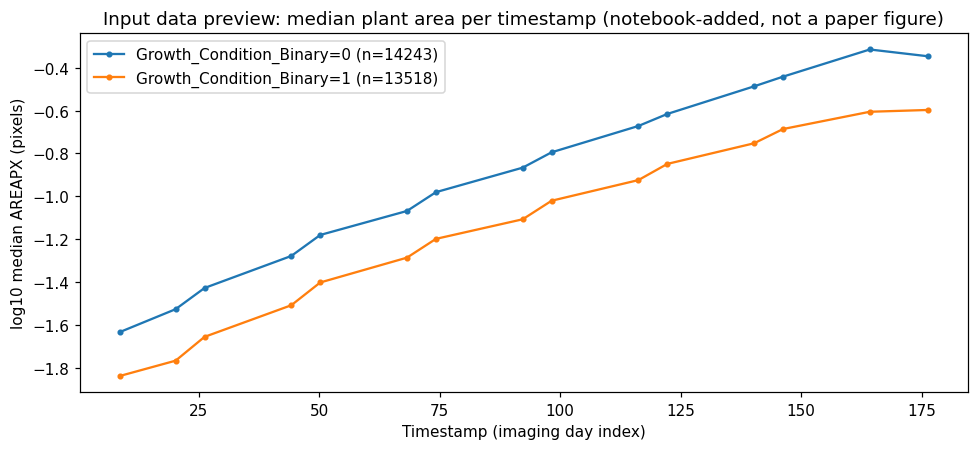

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 4.2), dpi=110)
for val, grp in df.groupby("Growth_Condition_Binary"):
    med = grp.groupby("Timestamp")["AREA_PX"].median()
    ax.plot(med.index, np.log10(med.values), marker="o", ms=3,
            label=f"Growth_Condition_Binary={val} (n={len(grp)})")
ax.set_xlabel("Timestamp (imaging day index)"); ax.set_ylabel("log10 median AREAPX (pixels)")
ax.set_title("Input data preview: median plant area per timestamp (notebook-added, not a paper figure)")
ax.legend(); fig.tight_layout(); plt.show()

## 5. Core method — the authors' HTDA-Mapper pipeline (Poincaré-ball branch)

**Purpose:** run the authors' descriptor-branch HTDA-Mapper with their tuned Poincaré-ball configuration (`configs/DesVisPBConfig.yaml`, read with the authors' `load_config`):

| Step | Authors' code (unmodified) | Parameters from the YAML |
| --- | --- | --- |
| Filter | `utils/HypUMAP.py` `HyperbolicUMAP` (UMAP, cosine, `output_metric='hyperboloid'` → Poincaré disk) | n_neighbors 303, min_dist 0.4591, spread 0.6500, n_epochs 500, random_state 48 |
| Cover | `utils/HypKmeansCover.py` `GeomstatsKMeansCover` (Riemannian k-means in the Poincaré ball + overlap) | n_clusters 194, overlap_threshold 0.31259 |
| Clusterer | `utils/HypDBSCAN.py` `HyperbolicDBSCAN` (Poincaré-ball distances, per cover element) | eps 0.61776, min_samples 49, dimension 2 |
| Colouring | `utils/TargetCounts.py` `custom_nutrition` node statistic + `utils/ExtractAssignCol.py` `generate_color_mapping` | target `Growth_Condition_Binary` |
| Global seed | `random.seed(9)` | `random_seed: 9` |

As in gtda's default Mapper (which the authors' `VisPipelineDes.py` used), clustering runs on the **filtered 2-D embedding** inside each cover element, nodes are (cover element, cluster) pairs joined when they share points, and label −1 (noise) points join no node. **Expected:** the hyperbolic UMAP embedding (norm < 1 on the Poincaré disk) for all 27,761 plants, with timings printed.

**日本語:** 著者の HTDA-Mapper（ポアンカレ球ブランチ）をチューニング済み設定で実行します。まず HyperbolicUMAP で全 27,761 植物をポアンカレ円板へ埋め込みます。


In [ ]:
%%time
import sys, random, numpy as np, pandas as pd
sys.path.insert(0, str(WS))
random.seed(9)                                   # author: random_seed 9
import geomstats.backend as gs
gs.random.seed(9)                                # author seed for geomstats

from utils.LoadConfig import load_config
from utils.HypUMAP import HyperbolicUMAP

config = load_config(str(WS / "configs/DesVisPBConfig.yaml"))
filter_params = config["hyper_params"]["Filter"]
print("config:", config)

data_for_mapper = df[data_columns].to_numpy(dtype=float)   # authors use df.columns[1:8]
t0 = __import__("time").time()
hyper_umap = HyperbolicUMAP(**filter_params)
E = hyper_umap.fit_transform(data_for_mapper)              # 2-D Poincaré disk embedding
t1 = __import__("time").time()
norms = np.linalg.norm(E, axis=1)
print(f"HyperbolicUMAP: {E.shape} in {t1-t0:.1f} s; max Poincare norm {norms.max():.4f} (<1 expected)")
assert norms.max() < 1.0

config: {'hyper_params': {'Filter': {'n_neighbors': 303, 'metric': 'cosine', 'min_dist': 0.45911607470666155, 'spread': 0.6500282894531771, 'n_epochs': 500, 'random_state': 48, 'n_components': 2}, 'Cover': {'n_clusters': 194, 'overlap_threshold': 0.31259492382798537}, 'Cluster': {'eps': 0.6177554929748442, 'min_samples': 49, 'dimension': 2}}, 'mapper_params': {'path_to_data': 'datasets/DesVisPE.csv', 'layout': 'kamada_kawai', 'layout_dim': 2, 'node_scale': 15}, 'random_seed': 9, 'space': 'poincareball'}


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


HyperbolicUMAP: (27761, 2) in 535.5 s; max Poincare norm 0.9833 (<1 expected)
CPU times: user 8min 54s, sys: 1.57 s, total: 8min 56s
Wall time: 8min 55s


**Purpose:** build the pullback cover with the authors' `GeomstatsKMeansCover` (194 Riemannian k-means clusters + 0.3126 overlap) on the embedding, then cluster each cover element with the authors' `HyperbolicDBSCAN` and assemble the Mapper graph: nodes are (cover element, non-noise cluster) pairs with their member indices; edges connect nodes sharing at least one plant. **Expected:** a node/edge count printout; this is the most time-consuming step (Riemannian k-means on 27,761 × 194).

**日本語:** 著者の Riemannian k-means カバー（194 クラスタ）でプルバックカバーを作り、各カバー要素内で HyperbolicDBSCAN によりクラスタリングして Mapper グラフを組み立てます（最も時間のかかる工程）。


In [ ]:
%%time
from utils.HypKmeansCover import GeomstatsKMeansCover
from utils.HypDBSCAN import HyperbolicDBSCAN

cover_params = config["hyper_params"]["Cover"]
cluster_params = config["hyper_params"]["Cluster"]
cover = GeomstatsKMeansCover(**cover_params, precomputed_centers=None)
cover.fit(E)                                               # Riemannian k-means -> cluster_centers_
M = cover.transform(E)                                     # bool (n_samples, n_clusters)
print("cover matrix:", M.shape, "avg memberships/point:", M.sum(1).mean().round(2))

import networkx as nx
G = nx.Graph()
node_members = {}
node_id = 0
for c in range(M.shape[1]):
    idx = np.where(M[:, c])[0]
    if idx.size < cluster_params["min_samples"]:
        continue
    labels = HyperbolicDBSCAN(**cluster_params).fit_predict(E[idx])
    for k in sorted(set(labels) - {-1}):
        members = idx[labels == k]
        G.add_node(node_id); node_members[node_id] = members
        node_id += 1
print("nodes after per-element clustering:", G.number_of_nodes())

# nerve: connect nodes sharing at least one data point (gtda default)
point2nodes = {}
for n, mem in node_members.items():
    for p in mem.tolist():
        point2nodes.setdefault(p, []).append(n)
for p, ns in point2nodes.items():
    for i in range(len(ns)):
        for j in range(i + 1, len(ns)):
            G.add_edge(ns[i], ns[j])
print("Mapper graph:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")
assert G.number_of_nodes() > 0, "no clusters found; check parameters" 

cover matrix: (27761, 194) avg memberships/point: 1.29


nodes after per-element clustering: 194
Mapper graph: 194 nodes, 530 edges
CPU times: user 5min 2s, sys: 706 ms, total: 5min 3s
Wall time: 5min 5s


**Purpose:** render the graph exactly in the style of the authors' `visualize_mapper_graph`: `kamada_kawai` 2-D layout (`mapper_params` in the YAML), marker size `node_scale` 15, nodes coloured by the authors' `custom_nutrition` statistic (1 if >50% of the node's plants are low-nutrient) mapped through the authors' `generate_color_mapping`, plotly white template 1200×700, and saved to `Visualisations/mapper_graph_Growth_Condition_Binaryseed9.png` via kaleido — the same filename the authors' script writes. **Expected:** a PNG file on the Colab VM.

**日本語:** 著者の `visualize_mapper_graph` と同じスタイル（kamada_kawai レイアウト、custom_nutrition によるノード色）で plotly 図を描画し、著者スクリプトと同じファイル名で PNG 保存します。


In [ ]:
%%time
from utils.TargetCounts import custom_nutrition
from utils.ExtractAssignCol import generate_color_mapping
import plotly.graph_objects as go

layout = nx.kamada_kawai_layout(G)
pos = np.array([layout[n] for n in G.nodes])

target_column = "Growth_Condition_Binary"                  # author entry point
color_variable = df[target_column].values
color_map = generate_color_mapping(df, target_column)
node_stat = [custom_nutrition(color_variable[node_members[n]]) for n in G.nodes]
node_colors = [color_map.get(v, "#000000") for v in node_stat]

fig = go.Figure()
xe, ye = pos[:, 0], pos[:, 1]
for u, v in G.edges():
    fig.add_trace(go.Scatter(x=[xe[u], xe[v]], y=[ye[u], ye[v]], mode="lines",
                             line=dict(width=0.5, color="gray"), hoverinfo="skip", showlegend=False))
fig.add_trace(go.Scatter(x=xe, y=ye, mode="markers",
                         marker=dict(size=config["mapper_params"]["node_scale"], color=node_colors),
                         text=[f"node {n}: Growth_Condition_Binary={node_stat[i]} (n={len(node_members[n])})"
                               for i, n in enumerate(G.nodes)],
                         hoverinfo="text", showlegend=False))
fig.update_layout(title_text=f"Mapper Graph for {target_column}", showlegend=True,
                  template="plotly_white", width=1200, height=700)

out_dir = WS / "Visualisations"; out_dir.mkdir(exist_ok=True)
out_png = out_dir / f"mapper_graph_{target_column}seed{config['random_seed']}.png"
fig.write_image(str(out_png))
print("written:", out_png, out_png.stat().st_size, "bytes")

written: /content/mml/Visualisations/mapper_graph_Growth_Condition_Binaryseed9.png 166645 bytes
CPU times: user 2.65 s, sys: 153 ms, total: 2.8 s
Wall time: 5.24 s


## 6. Result: HTDA-Mapper graph of the descriptor dataset

**Purpose:** display the graph produced above — this run's actual result, comparable to the paper's Fig. 5 (Poincaré-ball descriptor branch): nodes coloured by dominant growth condition, hyperbolic geometry from the Poincaré-ball embedding and cover. **Expected:** a Mapper graph whose branching reflects nutrient-regime/compound/concentration/time structure; the paper reports that the hyperbolic filter renders the growth timeline non-linearly, unlike the Euclidean version.

**日本語:** 上で生成したグラフ（この実行の実際の結果、論文 Fig. 5 相当）を表示します。ノード色は成長条件（栄養レジーム）の優勢度（`custom_nutrition`）です。


Result of this run (authors' hyperbolic components; adapted assembly):


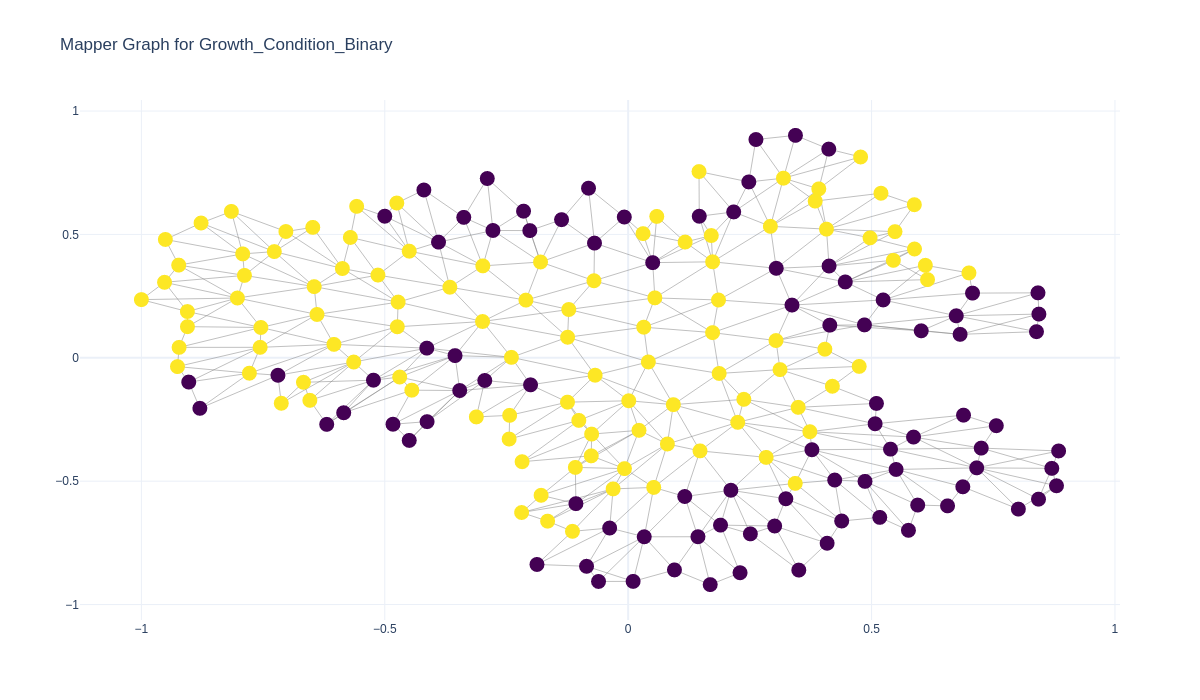

In [ ]:
from IPython.display import Image, display

out_png = WS / "Visualisations" / "mapper_graph_Growth_Condition_Binaryseed9.png"
print("Result of this run (authors' hyperbolic components; adapted assembly):")
display(Image(filename=str(out_png), width=1100))

### Quantitative summary and CSV export

**Purpose:** a small inspectable table of this run's graph (node count, edge count, nodes by dominant condition, node size distribution) plus a CSV export of the per-node table. **Expected:** a short table consistent with the printed graph statistics; `mapper_nodes.csv` written on the Colab VM.

**日本語:** 生成グラフの要約表（ノード数・エッジ数・優勢条件別ノード数など）を表示し、CSV に書き出します。


In [ ]:
import pandas as pd

node_rows = [{"node": n,
              "n_plants": len(node_members[n]),
              "dominant_Growth_Condition_Binary": custom_nutrition(color_variable[node_members[n]]),
              "x": float(pos[i][0]), "y": float(pos[i][1])}
             for i, n in enumerate(G.nodes)]
nodes_df = pd.DataFrame(node_rows)
print("nodes:", len(nodes_df), "| edges:", G.number_of_edges())
print("nodes by dominant condition:", dict(nodes_df["dominant_Growth_Condition_Binary"].value_counts()))
print("node size (plants) describe:", nodes_df["n_plants"].describe()[["min","25%","50%","75%","max"]].to_dict())
nodes_df.to_csv("/content/mapper_nodes.csv", index=False)
print("saved /content/mapper_nodes.csv")

nodes: 194 | edges: 530
nodes by dominant condition: {1: np.int64(105), 0: np.int64(89)}
node size (plants) describe: {'min': 87.0, '25%': 157.0, '50%': 182.0, '75%': 213.5, 'max': 295.0}
saved /content/mapper_nodes.csv


## 7. Interpretation and validation record

- **What was executed:** the authors' Poincaré-ball descriptor-branch HTDA-Mapper — their `HyperbolicUMAP` filter, `GeomstatsKMeansCover`, `HyperbolicDBSCAN`, `custom_nutrition` colouring and tuned `DesVisPBConfig.yaml`, all unmodified from commit `dac54cff` — on their full embedded 27,761-plant descriptor table, on a fresh Colab CPU runtime. The Mapper assembly and plotly rendering were reimplemented (see the notice at the top) because giotto-tda has no Python 3.13 wheels on Colab.
- **What this does and does not show:** this single-example run reproduces the *method and its tuned configuration* on the authors' data; the paper's Fig. 5 was produced by the same scientific components, so broad structural agreement (hyperbolic, non-linear arrangement of nutrient-regime branches) is expected, but node-level identity of the graph is **not** claimed across library versions. No dataset-level benchmark from the paper is verified here.
- **Known limitations:** partial demonstration (image branch and contrastive learning out of scope); the repository has no licence file (GitHub API reports license: null) — reuse terms must be verified separately; runtime depends on geomstats/umap versions pinned in the install cell.
- **日本語:** 著者の双曲コンポーネントを改変せず用いた部分的再現です。単一実行により手法とチューニング設定の動作を確認できますが、論文のノードレベルの一致やデータセット全体の評価は検証していません。画像ブランチとコントラスティブ学習は対象外、リポジトリにライセンスファイルがない点に注意してください。

**References:** Plant Phenomics 2026;8:100186 (PMC13316264); JZdrazilX/MML @ `dac54cfff85e41f002e1fd6adade506129dd4112`; Zenodo record 17952279 (`dataset_plants.csv` is an open cc-by-4.0 copy of the same descriptor table).
